In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score,classification_report

from sklearn.ensemble import RandomForestClassifier

import joblib

In [9]:
df=pd.read_csv("airline_dataset.csv")
df.head()

,Flight,Airline,Origin,Destination,Departure Time,Arrival Time,Distance,Weather,Delay
0,AI101,Air India,Delhi,Mumbai,06:30,08:40,1150,Sunny,0
1,6E202,IndiGo,Mumbai,Bengaluru,07:15,09:00,980,Cloudy,15
2,SG305,SpiceJet,Chennai,Delhi,08:00,10:45,1760,Rain,42
3,AK410,Akasa Air,Bengaluru,Goa,09:30,10:45,560,Sunny,0
4,IX512,Air India Express,Kochi,Hyderabad,10:15,11:55,1050,Fog,28


In [ ]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.drop_duplicates(inplace=True)
df['Departure Hour'] = pd.to_datetime(df['Departure Time'],format='%H:%M').dt.hour
df['Delay_Status']=df['Delay'].apply(lambda x:1 if x>0 else 0)


<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Flight          192 non-null    str  
 1   Airline         192 non-null    str  
 2   Origin          192 non-null    str  
 3   Destination     192 non-null    str  
 4   Departure Time  192 non-null    str  
 5   Arrival Time    192 non-null    str  
 6   Distance        192 non-null    int64
 7   Weather         192 non-null    str  
 8   Delay           192 non-null    int64
 9   Departure Hour  192 non-null    int32
dtypes: int32(1), int64(2), str(7)
memory usage: 14.4 KB


In [37]:
df.to_csv("reports/analysis_report.csv", index=False)
plt.savefig("reports/delay_chart.png")

<Figure size 640x480 with 0 Axes>

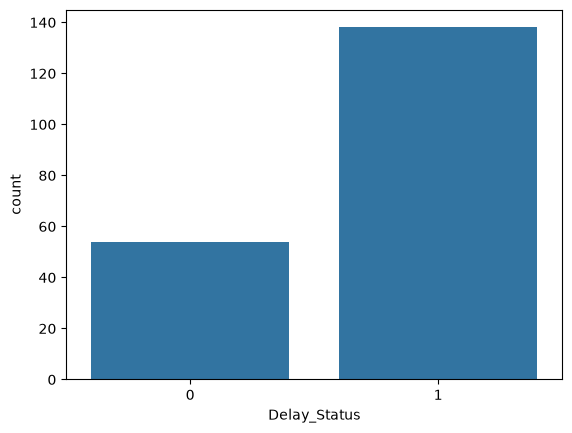

In [17]:
sns.countplot(x="Delay_Status",data=df)
plt.show()

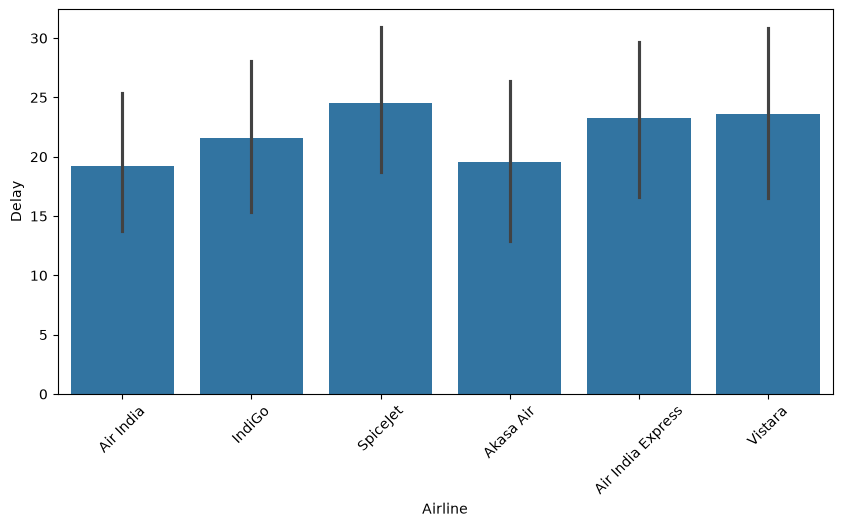

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x="Airline",y="Delay",data=df)
plt.xticks(rotation=45)
plt.show()

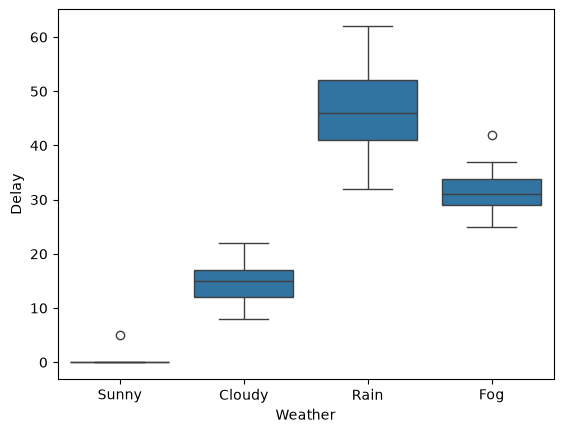

In [19]:
sns.boxplot(x="Weather",y="Delay",data=df)
plt.show()

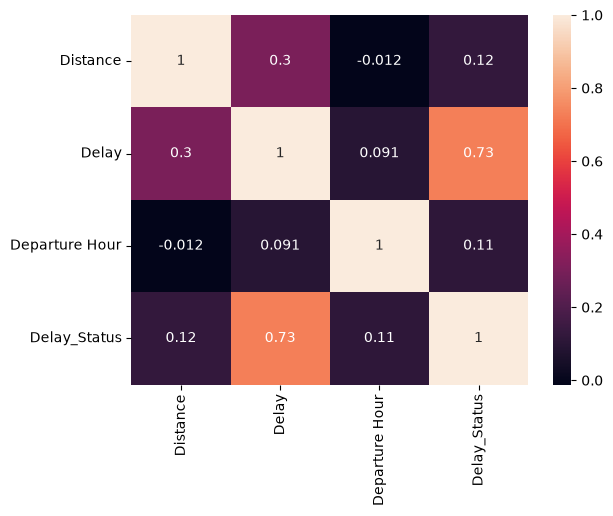

In [20]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [ ]:
encoder={}
columns=["Airline","Origin","Destination","Weather"]
for col in columns:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    encoder[col]=le

In [22]:
X=df[["Airline","Origin","Destination","Departure Hour","Distance","Weather"]]
y=df["Delay_Status"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [24]:
model=RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
prediction=model.predict(X_test)
accuracy_score(y_test,prediction)

print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        28

    accuracy                           1.00        39
   macro avg       1.00      1.00      1.00        39
weighted avg       1.00      1.00      1.00        39



In [34]:
import joblib
model = joblib.load("delay_model.pkl")